# What does a correct run of the lab reach, and what does each trap print?

**TRAINER ONLY.** Week 1, Friday. The data is `v3-lab`, **proposed for client zero v2.3** and
not yet locked, so a number here can still move when the lock lands; rerun this notebook then.

**Who needs the answer.** The trainer, who says the morning's numbers aloud at the debrief, and the
TAs, who read a learner's screen from across the room during the lab and name each stall on the
observation sheet. A number misremembered here becomes a wrong correction to a learner.

**The questions on the way.** What does the file hold before any change? Which rows count, and
what does each decision log? Does the clean data land on Finance's control totals? Which branch
moved, in which segment? Which routes can a correct run take to the test, and what does each print?
What does the note say when a correct run writes it? And what does the practice export reach?

Kavya's terms for the day: "Before anything goes to Meera, rebuild the week from a raw export
with no assistant and no notes. Then say it to me the way you will say it to her."

This notebook is the run a careful analyst makes in about ninety minutes, with each trap a
hurried run falls into computed beside it, exactly, so a TA can recognise a wrong number on a
learner's screen from across the room. Every figure in the lab key and the day sheet comes from
a printed cell below.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import random
import math
import statistics

rows = kit.load_csv("C2_W01_D05_lab_orders_STUDENT.csv")
control = {c["quarter"]: c for c in kit.load_csv("C2_W01_D05_lab_control_STUDENT.csv")}
print(f"{len(rows)} rows read; control totals for {sorted(control)}")
print(rows[0])

207 rows read; control totals for ['Q1', 'Q2']
{'order_id': 'KR-07001', 'customer_id': 'C-7024', 'segment': 'Retail-Core', 'channel': 'app', 'city': 'Bengaluru', 'order_date': '2026-04-02', 'quarter': 'Q1', 'amount': '1370'}


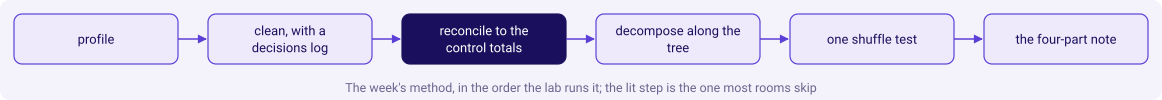

In [2]:
kit.flow(["profile", "clean, with a decisions log", "reconcile to the control totals",
          "decompose along the tree", "one shuffle test", "the four-part note"], lit=2,
         title="The week's method, in the order the lab runs it; the lit step is the one most rooms skip")

## 1. What does the file hold before any change?

The profile takes three counts per field: present, convertible where a number is expected, and
distinct. The finding of the profile is every place where a count disagrees with what the field
should hold.

In [3]:
def profile(records, field, numeric=False):
    present = [r[field] for r in records if r.get(field, "") != ""]
    convertible = None
    if numeric:
        convertible = 0
        for v in present:
            try:
                int(v)
                convertible += 1
            except ValueError:
                pass
    return len(present), convertible, len(set(present))


fields = list(rows[0])
prof = {f: profile(rows, f, numeric=(f == "amount")) for f in fields}
kit.table(["field", "present", "convertible", "distinct"],
          [(f, p, "" if c is None else c, d) for f, (p, c, d) in prof.items()],
          caption=f"The profile of {len(rows)} rows, before any decision")

field,present,convertible,distinct
order_id,207,,197
customer_id,207,,67
segment,206,,4
channel,207,,3
city,207,,5
order_date,207,,118
quarter,207,,2
amount,207,206,145


In [4]:
ids = [r["order_id"] for r in rows]
kit.check("207 rows carry 197 distinct order ids, so ten rows repeat an id",
          len(rows) == 207 and len(set(ids)) == 197, f"{len(rows)} rows, {len(set(ids))} ids")
kit.check("one amount will not convert and one segment is empty",
          prof["amount"][1] == 206 and prof["segment"][0] == 206)

**Trap 6, the typical order.** A hurried profile reports the mean order as the typical
one. The median is the honest answer, because ten corporate orders sit above Rs 7 lakh while
every consumer order sits under Rs 4,000.

In [5]:
amounts_all = sorted(int(r["amount"]) for r in rows if r["amount"].isdigit())
kit.table(["measure", "on the rows that convert, duplicates still in"],
          [("mean order", kit.rupees(statistics.mean(amounts_all))),
           ("median order", kit.rupees(statistics.median(amounts_all)))],
          caption="The mean is the wrong typical order by a factor of about 25")

measure,"on the rows that convert, duplicates still in"
mean order,"Rs 52,057"
median order,"Rs 2,110"


## 2. Which rows count, and what does each decision log?

The pass makes three decisions, each logged with its row count as it is made. The identity rule
is the order id: two rows with one id are one order. The corporate amount written with Indian digit grouping
is a real order stored as text, so it is read, converted and flagged in the log. The empty
segment is restored from the same customer's other orders, flagged, because every one of that
customer's other orders carries one segment.

In [6]:
log, clean, rejected, seen, first_raw = [], [], [], {}, {}
customer_segment = {}
for r in rows:
    if r["segment"]:
        customer_segment.setdefault(r["customer_id"], set()).add(r["segment"])

for r in rows:
    r = dict(r)
    first_raw.setdefault(r["order_id"], dict(r))
    if r["order_id"] in seen:
        same = first_raw[r["order_id"]] == r
        rejected.append(r)
        log.append({"order_id": r["order_id"], "decision": "drop",
                    "reason": "second row of an order already kept" + ("" if same else ", fields differ")})
        continue
    if not r["amount"].isdigit():
        digits = r["amount"].replace(",", "")
        log.append({"order_id": r["order_id"], "decision": "convert and flag",
                    "reason": f"amount stored as text {r['amount']!r}, read as {digits}"})
        r["amount"] = digits
    if r["segment"] == "":
        segs = customer_segment.get(r["customer_id"], set())
        log.append({"order_id": r["order_id"], "decision": "default and flag",
                    "reason": f"segment empty; the customer's other orders are all {sorted(segs)}"})
        r["segment"] = sorted(segs)[0]
    r["amount"] = int(r["amount"])
    seen[r["order_id"]] = r
    clean.append(r)

kit.table(["decision", "rows"],
          [(d, sum(1 for e in log if e["decision"] == d)) for d in ("drop", "convert and flag", "default and flag")],
          caption="The decisions log, counted")

decision,rows
drop,10
convert and flag,1
default and flag,1


In [7]:
kit.check("every dropped row repeats an order kept, field for field",
          all("differ" not in e["reason"] for e in log if e["decision"] == "drop"))
kit.check("the restored segment comes from a customer with one segment only",
          all(len(customer_segment[r["customer_id"]]) == 1 for r in clean))

**Trap 2, the pass that looks clean.** A hurried pass wraps `int()` in a try and sets a
failure to zero. It reports no rejects, the row count reconciles, and Q1 is short by the whole
corporate order.

In [8]:
def coerce(v):
    try:
        return int(v)
    except ValueError:
        return 0


zeroed_q1 = sum(coerce(r["amount"]) for r in {r["order_id"]: r for r in rows}.values() if r["quarter"] == "Q1")
print(f"Q1 on the zero-coercing pass: {kit.rupees(zeroed_q1)}, 98 orders, 0 rejects")
print(f"Q1 in Finance's control totals: {kit.rupees(int(control['Q1']['amount_rs']))}, {control['Q1']['orders']} orders")
kit.check("the counts reconcile while the rupees do not",
          zeroed_q1 != int(control["Q1"]["amount_rs"]), kit.rupees(int(control["Q1"]["amount_rs"]) - zeroed_q1))

Q1 on the zero-coercing pass: Rs 50,63,000, 98 orders, 0 rejects
Q1 in Finance's control totals: Rs 60,48,000, 98 orders


## 3. Does the clean data land on Finance's control totals?

This is the step most rooms skip when the clock runs, and it is the only one that catches both
the batch posted twice and the amount lost as text.

In [9]:
by_q = {q: [r for r in clean if r["quarter"] == q] for q in ("Q1", "Q2")}
kit.table(["quarter", "clean orders", "control orders", "clean rupees", "control rupees"],
          [(q, len(by_q[q]), control[q]["orders"], kit.rupees(sum(r["amount"] for r in by_q[q])),
            kit.rupees(int(control[q]["amount_rs"]))) for q in ("Q1", "Q2")],
          caption="Clean against Finance's control totals")
kit.check("input equals clean plus rejected", len(rows) == len(clean) + len(rejected),
          f"{len(rows)} = {len(clean)} + {len(rejected)}")
kit.check("both quarters land on the control totals, orders and rupees",
          all(len(by_q[q]) == int(control[q]["orders"]) and
              sum(r["amount"] for r in by_q[q]) == int(control[q]["amount_rs"]) for q in by_q))

quarter,clean orders,control orders,clean rupees,control rupees
Q1,98,98,"Rs 60,48,000","Rs 60,48,000"
Q2,99,99,"Rs 43,25,480","Rs 43,25,480"


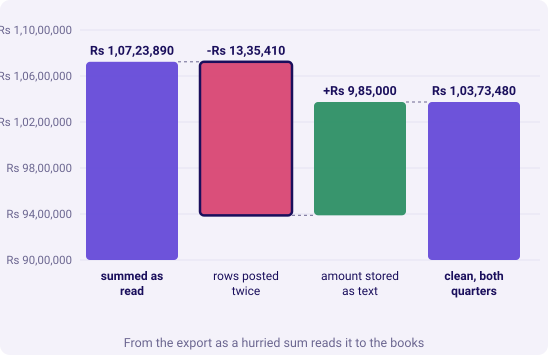

as read Rs 1,07,23,890, duplicates -Rs 13,35,410, text amount +Rs 9,85,000, lands on Rs 1,03,73,480


In [10]:
as_read = sum(int(r["amount"]) for r in rows if r["amount"].isdigit())
dupes = -sum(int(r["amount"]) for r in rejected)
text_back = sum(r["amount"] for r in clean if any(e["order_id"] == r["order_id"] and
                e["decision"] == "convert and flag" for e in log))
kit.bridge(("summed as read", as_read),
           [("rows posted twice", dupes), ("amount stored as text", text_back)],
           end_label="clean, both quarters",
           title="From the export as a hurried sum reads it to the books", lit=[0], lo=9_000_000)
print(f"as read {kit.rupees(as_read)}, duplicates {kit.rupees(dupes)}, text amount +{kit.rupees(text_back)}, "
      f"lands on {kit.rupees(as_read + dupes + text_back)}")

**Trap 1, the reconciliation skipped, the one most rooms fall into.** A run that keeps
the repeated rows and loses the text amount compares two wrong quarters and reports growth. Each
half of the mistake on its own gives a different wrong number, and all three are below.

In [11]:
def total(q, keep_dupes, text_ok):
    src = rows if keep_dupes else list({r["order_id"]: r for r in rows}.values())
    out = 0
    for r in src:
        if r["quarter"] != q:
            continue
        v = r["amount"]
        out += int(v.replace(",", "")) if text_ok else (int(v) if v.isdigit() else 0)
    return out


def change(a, b):
    return 100 * (b / a - 1)


variants = [("the reconciled run", False, True), ("duplicates kept, text read correctly", True, True),
            ("duplicates removed, text set to zero", False, False), ("both mistakes, the hurried run", True, False)]
kit.table(["run", "Q1", "Q2", "Q1 to Q2"],
          [(name, kit.rupees(total("Q1", d, t)), kit.rupees(total("Q2", d, t)),
            f"{change(total('Q1', d, t), total('Q2', d, t)):+.1f}%") for name, d, t in variants],
          caption="One export, four headlines")
honest = change(total("Q1", False, True), total("Q2", False, True))
hurried = change(total("Q1", True, False), total("Q2", True, False))
kit.check("the hurried run reports growth where the books show a fall", hurried > 0 > honest,
          f"{hurried:+.1f}% against {honest:+.1f}%")

run,Q1,Q2,Q1 to Q2
the reconciled run,"Rs 60,48,000","Rs 43,25,480",-28.5%
"duplicates kept, text read correctly","Rs 60,48,000","Rs 56,60,890",-6.4%
"duplicates removed, text set to zero","Rs 50,63,000","Rs 43,25,480",-14.6%
"both mistakes, the hurried run","Rs 50,63,000","Rs 56,60,890",+11.8%


## 4. Which branch moved, in which segment?

Revenue is customers, times orders per customer, times revenue per order. The total moved; the
tree says which branch, in which segment.

In [12]:
SEGS = ("Retail-Core", "Retail-Plus", "Student", "Business")


def tree(src, q, seg):
    rs = [r for r in src if r["quarter"] == q and r["segment"] == seg]
    cust = len({r["customer_id"] for r in rs})
    rev = sum(int(r["amount"]) for r in rs)
    return len(rs), cust, len(rs) / cust, rev / len(rs), rev


rows_out = []
for seg in SEGS:
    a, b = tree(clean, "Q1", seg), tree(clean, "Q2", seg)
    rows_out.append((seg, f"{a[1]} / {b[1]}", f"{a[2]:.2f} / {b[2]:.2f}",
                     f"{kit.rupees(a[3])} / {kit.rupees(b[3])}", f"{change(a[4], b[4]):+.1f}%", f"{a[0]} / {b[0]}"))
kit.table(["segment", "customers Q1 / Q2", "orders per customer", "revenue per order", "revenue", "orders"],
          rows_out, caption="The tree, clean, Q1 against Q2")

segment,customers Q1 / Q2,orders per customer,revenue per order,revenue,orders
Retail-Core,30 / 30,1.47 / 1.47,"Rs 2,050 / Rs 1,700",-17.1%,44 / 44
Retail-Plus,20 / 20,1.70 / 1.75,"Rs 2,800 / Rs 2,760",+1.5%,34 / 35
Student,12 / 12,1.17 / 1.33,Rs 900 / Rs 880,+11.7%,14 / 16
Business,5 / 4,1.20 / 1.00,"Rs 9,75,000 / Rs 10,35,000",-29.2%,6 / 4


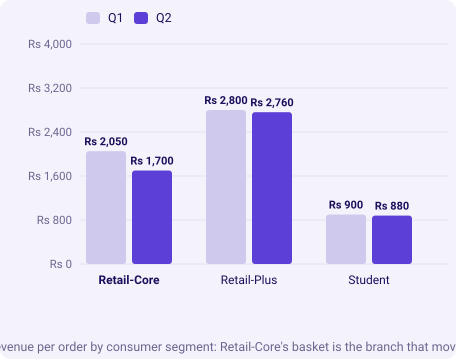

The fall is Rs 17,22,520; Business carries Rs 17,10,000 of it, 99.3 percent, on 6 orders then 4


In [13]:
consumer = SEGS[:3]
kit.columns(list(consumer), [("Q1", [tree(clean, "Q1", s)[3] for s in consumer]),
                             ("Q2", [tree(clean, "Q2", s)[3] for s in consumer])],
            title="Revenue per order by consumer segment: Retail-Core's basket is the branch that moved",
            fmt=lambda v: kit.rupees(v), lit=[0])
biz = tree(clean, "Q1", "Business")[4] - tree(clean, "Q2", "Business")[4]
whole = int(control["Q1"]["amount_rs"]) - int(control["Q2"]["amount_rs"])
print(f"The fall is {kit.rupees(whole)}; Business carries {kit.rupees(biz)} of it, {100 * biz / whole:.1f} percent, "
      f"on {tree(clean, 'Q1', 'Business')[0]} orders then {tree(clean, 'Q2', 'Business')[0]}")

In [14]:
core1, core2 = tree(clean, "Q1", "Retail-Core"), tree(clean, "Q2", "Retail-Core")
kit.check("Retail-Core's customers and frequency hold while its basket falls",
          core1[1] == core2[1] and abs(core1[2] - core2[2]) < 0.01 and change(core1[3], core2[3]) < -15,
          f"{change(core1[3], core2[3]):+.1f}% per order")
kit.check("the corporate fall rests on fewer than thirty orders",
          tree(clean, "Q1", "Business")[0] + tree(clean, "Q2", "Business")[0] < 30)

**Trap 3, the wrong branch.** On the uncleaned rows Retail-Core's customers seem to
order about a fifth more often in Q2, which cancels the basket fall and reads the segment as
flat. The frequency rise is the repeated batch and nothing else.

In [15]:
h1 = tree([r for r in rows if r["segment"] and r["amount"].isdigit()], "Q1", "Retail-Core")
h2 = tree([r for r in rows if r["segment"] and r["amount"].isdigit()], "Q2", "Retail-Core")
kit.table(["Retail-Core", "orders per customer", "revenue per order", "revenue"],
          [("hurried Q1", f"{h1[2]:.2f}", kit.rupees(h1[3]), kit.rupees(h1[4])),
           ("hurried Q2", f"{h2[2]:.2f}", kit.rupees(h2[3]), kit.rupees(h2[4])),
           ("hurried change", f"{change(h1[2], h2[2]):+.1f}%", f"{change(h1[3], h2[3]):+.1f}%", f"{change(h1[4], h2[4]):+.1f}%"),
           ("clean change", f"{change(core1[2], core2[2]):+.1f}%", f"{change(core1[3], core2[3]):+.1f}%",
            f"{change(core1[4], core2[4]):+.1f}%")],
          caption="The repeated rows turn a basket problem into a flat segment")
kit.check("the hurried run shows frequency up and revenue flat in Retail-Core",
          change(h1[2], h2[2]) > 15 and abs(change(h1[4], h2[4])) < 1)

Retail-Core,orders per customer,revenue per order,revenue
hurried Q1,1.47,"Rs 2,050","Rs 90,200"
hurried Q2,1.77,"Rs 1,702","Rs 90,210"
hurried change,+20.5%,-17.0%,+0.0%
clean change,+0.0%,-17.1%,-17.1%


## 5. Which routes can a correct run take to the test, and what does each print?

The note's claim is that Retail-Core's revenue per order fell from Q1 to Q2 while its 30
customers and their frequency held. The same 30 customers sit in both quarters, so the fair test
for that claim keeps each customer's own two quarters together and flips them at random: a paired
sign-flip, 2,000 flips on `random.Random(7)`, with Retail-Core's revenue per order recomputed in
every world. The direction was chosen after the data was seen, so the verdict reports both
directions, and the one-way share is printed only so a TA recognises it on a screen.

Learners reach other routes, and the key accepts every route that keeps each customer's orders
together for the question it answers. A route that pools a customer's two quarters, or shuffles
single orders, is the hurried mistake and sits among the traps.

Retail-Core revenue per order -17.1%, each customer's two quarters flipped: 2,000 flips 0.0060 both ways (0.0010 one way); 20,000 flips 0.0042 (0.0003); exact over 2^30 flips 0.0035 (0.0004)


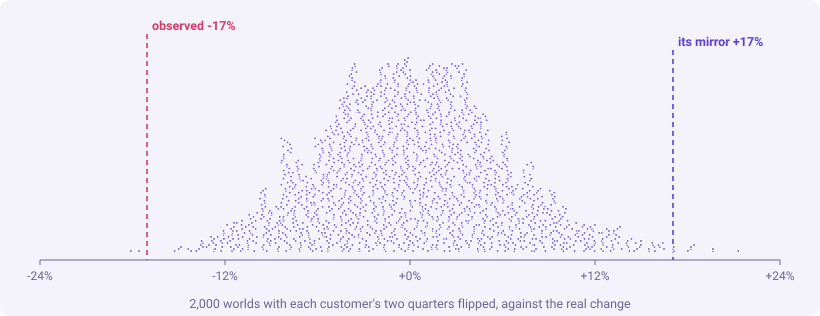

In [16]:
def basket_change(rs):
    a = [r["amount"] for r in rs if r["quarter"] == "Q1"]
    b = [r["amount"] for r in rs if r["quarter"] == "Q2"]
    return change(sum(a) / len(a), sum(b) / len(b))


def members_of(rs):
    """Each customer with their own Q1 and Q2 amounts, in customer order."""
    per = {}
    for r in rs:
        per.setdefault(r["customer_id"], {"Q1": [], "Q2": []})[r["quarter"]].append(r["amount"])
    return dict(sorted(per.items()))


def flipped(per, swaps):
    """The group's change in revenue per order with the swapped customers' two quarters exchanged."""
    q1r = q1n = q2r = q2n = 0
    for v, s in zip(per.values(), swaps):
        a, b = (v["Q2"], v["Q1"]) if s else (v["Q1"], v["Q2"])
        q1r, q1n, q2r, q2n = q1r + sum(a), q1n + len(a), q2r + sum(b), q2n + len(b)
    return change(q1r / q1n, q2r / q2n)


def paired(rs, flips=2000, seed=7):
    per = members_of(rs)
    obs = flipped(per, [False] * len(per))
    rng = random.Random(seed)
    worlds = [flipped(per, [rng.random() < 0.5 for _ in per]) for _ in range(flips)]
    both = sum(1 for w in worlds if abs(w) >= abs(obs) - 1e-9) / flips
    one = sum(1 for w in worlds if w <= obs + 1e-9) / flips
    return obs, both, one, worlds


core = [r for r in clean if r["segment"] == "Retail-Core"]
plus = [r for r in clean if r["segment"] == "Retail-Plus"]
student = [r for r in clean if r["segment"] == "Student"]
observed, p_paired, p_paired_one, worlds = paired(core)
_, p_paired_20k, p_paired_one_20k, _ = paired(core, flips=20000)

# The exact share over all 2^30 flips. Every Retail-Core customer has as many orders in Q2 as in Q1,
# so a flip moves only rupees, and the statistic is set by the flipped revenue difference.
per_core = members_of(core)
assert all(len(v["Q1"]) == len(v["Q2"]) for v in per_core.values())
diffs = [sum(v["Q2"]) - sum(v["Q1"]) for v in per_core.values()]
total_rev = sum(sum(v["Q1"]) + sum(v["Q2"]) for v in per_core.values())
dist = {0: 1}
for d in diffs:
    nxt = {}
    for s, c in dist.items():
        nxt[s + d] = nxt.get(s + d, 0) + c
        nxt[s - d] = nxt.get(s - d, 0) + c
    dist = nxt
exact_both = exact_one = 0
for s, c in dist.items():
    stat = change((total_rev - s) / 2, (total_rev + s) / 2)
    exact_both += c if abs(stat) >= abs(observed) - 1e-9 else 0
    exact_one += c if stat <= observed + 1e-9 else 0
exact_both, exact_one = exact_both / 2 ** len(diffs), exact_one / 2 ** len(diffs)
print(f"Retail-Core revenue per order {observed:+.1f}%, each customer's two quarters flipped: "
      f"2,000 flips {p_paired:.4f} both ways ({p_paired_one:.4f} one way); 20,000 flips {p_paired_20k:.4f} "
      f"({p_paired_one_20k:.4f}); exact over 2^30 flips {exact_both:.4f} ({exact_one:.4f})")
kit.strip(worlds, markers=[("observed", observed, "bad"), ("its mirror", -observed, "plain")], lo=-24, hi=24,
          fmt=lambda v: f"{v:+.0f}%", title="2,000 worlds with each customer's two quarters flipped, against the real change")

In [17]:
def label_shuffle(a_rows, b_rows, shuffles=2000, seed=7):
    """Segment labels shuffled across whole customers, each carrying all their orders."""
    obs = basket_change(a_rows) - basket_change(b_rows)
    groups = {}
    for r in a_rows + b_rows:
        groups.setdefault(r["customer_id"], []).append(r)
    ids = sorted(groups)
    n_a = len({r["customer_id"] for r in a_rows})
    rng = random.Random(seed)
    both = one = 0
    for _ in range(shuffles):
        m = ids[:]
        rng.shuffle(m)
        g = (basket_change([r for c in m[:n_a] for r in groups[c]])
             - basket_change([r for c in m[n_a:] for r in groups[c]]))
        both += abs(g) >= abs(obs)
        one += g <= obs
    return obs, both / shuffles, one / shuffles


gap_plus, p_plus, p_plus_one = label_shuffle(core, plus)
gap_others, p_others, p_others_one = label_shuffle(core, plus + student)

# Each customer's revenue in Q1 and Q2, and the two tests on that measure.
r1 = [sum(v["Q1"]) for v in per_core.values()]
r2 = [sum(v["Q2"]) for v in per_core.values()]
rng = random.Random(7)
p_rev = sum(1 for _ in range(2000)
            if abs(sum(d if rng.random() < 0.5 else -d for d in diffs)) >= abs(sum(diffs)) - 1e-9) / 2000
real = sum(r1) / len(r1) - sum(r2) / len(r2)
rng = random.Random(7)
pool, dealt = r1 + r2, []
for _ in range(2000):                       # the per-customer figures pooled and dealt, as a hurried run does
    rng.shuffle(pool)
    dealt.append(sum(pool[:len(r1)]) / len(r1) - sum(pool[len(r1):]) / len(r2))
p_pooled = sum(1 for g in dealt if abs(g) >= abs(real) - 1e-9) / 2000
p_pooled_one = sum(1 for g in dealt if g >= real - 1e-9) / 2000

# Retail-Core's orders from both quarters pooled and the quarter label dealt across single orders.
core_q1 = [r["amount"] for r in core if r["quarter"] == "Q1"]
core_q2 = [r["amount"] for r in core if r["quarter"] == "Q2"]
rng = random.Random(7)
pool_orders, q_both, q_one = core_q1 + core_q2, 0, 0
for _ in range(2000):
    rng.shuffle(pool_orders)
    g = change(sum(pool_orders[:len(core_q1)]) / len(core_q1), sum(pool_orders[len(core_q1):]) / len(core_q2))
    q_both += abs(g) >= abs(observed) - 1e-9
    q_one += g <= observed + 1e-9
p_qorders, p_qorders_one = q_both / 2000, q_one / 2000

fell = sum(1 for v in per_core.values() if sum(v["Q2"]) / len(v["Q2"]) < sum(v["Q1"]) / len(v["Q1"]))
rose = sum(1 for v in per_core.values() if sum(v["Q2"]) / len(v["Q2"]) > sum(v["Q1"]) / len(v["Q1"]))
p_sign = 2 * sum(math.comb(fell + rose, k) for k in range(min(fell, rose) + 1)) / 2 ** (fell + rose)

both_rows = core + plus
rng = random.Random(7)
ext_orders = ext_orders_one = 0
for _ in range(2000):
    idx = list(range(len(both_rows)))
    rng.shuffle(idx)
    g = (basket_change([both_rows[i] for i in idx[:len(core)]])
         - basket_change([both_rows[i] for i in idx[len(core):]]))
    ext_orders += abs(g) >= abs(gap_plus)
    ext_orders_one += g <= gap_plus

# The empty segment kept as a flagged unknown, outside Retail-Plus, with the segment sums reconciled.
plus_named = [r for r in plus if r["order_id"] != "KR-07146"]
q2_named = [r for r in plus_named if r["quarter"] == "Q2"]
gap_unknown, p_unknown, p_unknown_one = label_shuffle(core, plus_named)

routes = [
    ("each customer's two quarters flipped, revenue per order", "did Retail-Core's basket fall?", "fair, the note's test",
     f"{p_paired:.4f}", f"{p_paired_one:.4f}"),
    ("each customer's two quarters flipped, revenue per customer", "did Retail-Core's customers spend less?", "fair",
     f"{p_rev:.4f}", ""),
    (f"sign test, {fell} fell and {rose} rose", "did most customers' baskets fall?", "fair, the second route",
     f"{p_sign:.4f}", ""),
    ("segment label across the 50 Core and Plus customers", "did Core move differently from Plus?", "fair",
     f"{p_plus:.4f}", f"{p_plus_one:.4f}"),
    ("the same, the unknown order kept out of Plus", "did Core move differently from Plus?", "fair",
     f"{p_unknown:.4f}", f"{p_unknown_one:.4f}"),
    ("segment label across Core and every other consumer", "did Core move differently from the rest?", "fair",
     f"{p_others:.4f}", f"{p_others_one:.4f}"),
    ("per-customer revenue, Q1 and Q2 pooled and dealt", "did Retail-Core's customers spend less?",
     "pools paired data: trap 5b", f"{p_pooled:.4f}", f"{p_pooled_one:.4f}"),
    (f"quarter label dealt across Retail-Core's {len(core)} single orders", "did Retail-Core's basket fall?",
     "pools paired data order by order: trap 5b", f"{p_qorders:.4f}", f"{p_qorders_one:.4f}"),
    ("segment label across single orders", "did Core move differently from Plus?", "splits customers: trap 5",
     f"{ext_orders / 2000:.4f}", f"{ext_orders_one / 2000:.4f}"),
]
kit.table(["route, 2,000 on random.Random(7)", "the question it answers", "verdict", "p, both ways", "p, one way"],
          routes, caption="Every route a learner can take, with its number")
print(f"basket gap to Plus {gap_plus:+.1f} points; to every other consumer {gap_others:+.1f}; "
      f"with the unknown order kept out of Plus {gap_unknown:+.1f}, Plus Q2 {len(q2_named)} orders, "
      f"{kit.rupees(sum(r['amount'] for r in q2_named))}, "
      f"{change(sum(r['amount'] for r in plus_named if r['quarter'] == 'Q1'), sum(r['amount'] for r in q2_named)):+.1f}%")

"route, 2,000 on random.Random(7)",the question it answers,verdict,"p, both ways","p, one way"
"each customer's two quarters flipped, revenue per order",did Retail-Core's basket fall?,"fair, the note's test",0.0060,0.0010
"each customer's two quarters flipped, revenue per customer",did Retail-Core's customers spend less?,fair,0.0015,
"sign test, 21 fell and 9 rose",did most customers' baskets fall?,"fair, the second route",0.0428,
segment label across the 50 Core and Plus customers,did Core move differently from Plus?,fair,0.0195,0.0120
"the same, the unknown order kept out of Plus",did Core move differently from Plus?,fair,0.0230,0.0140
segment label across Core and every other consumer,did Core move differently from the rest?,fair,0.0345,0.0180
"per-customer revenue, Q1 and Q2 pooled and dealt",did Retail-Core's customers spend less?,pools paired data: trap 5b,0.0765,0.0325
quarter label dealt across Retail-Core's 88 single orders,did Retail-Core's basket fall?,pools paired data order by order: trap 5b,0.0035,0.0010
segment label across single orders,did Core move differently from Plus?,splits customers: trap 5,0.0755,0.0330


basket gap to Plus -15.6 points; to every other consumer -13.7; with the unknown order kept out of Plus -15.5, Plus Q2 34 orders, Rs 93,670, -1.6%


In [18]:
band = []
for seed in range(1, 21):
    band.append(paired(core, seed=seed)[1])
band_plus = [label_shuffle(core, plus, seed=seed)[1] for seed in range(1, 21)]
print(f"Seeds 1 to 20 at 2,000: the note's test from {min(band):.4f} to {max(band):.4f}; "
      f"Core against Plus from {min(band_plus):.4f} to {max(band_plus):.4f}")
kit.check("every fair route puts the finding below 0.05", max(p_paired, p_rev, p_sign, p_plus, p_unknown, p_others) < 0.05,
          f"the largest is {max(p_paired, p_rev, p_sign, p_plus, p_unknown, p_others):.4f}")
kit.check("the note's test stays below 0.05 on every seed tried", max(band) < 0.05, f"{min(band):.4f} to {max(band):.4f}")
kit.check("the flagged-unknown handling reads Plus Q2 as 34 orders and Rs 93,670",
          len(q2_named) == 34 and sum(r["amount"] for r in q2_named) == 93670)

Seeds 1 to 20 at 2,000: the note's test from 0.0005 to 0.0060; Core against Plus from 0.0145 to 0.0270


**Traps 5 and 5b, the wrong unit.** Both hurried routes split what belongs together.
Shuffling segment labels across single orders splits one customer's orders between the groups
(trap 5); pooling each customer's Q1 and Q2 figures and dealing the quarter labels treats a
customer's own two quarters as strangers (trap 5b), and so does dealing the quarter label across
Retail-Core's single orders from both quarters. Either can move p either way: most often a broken
pairing makes p too small, since correlated values count as extra evidence. Here the two pooled
and split routes come out larger than the fair tests, because each customer's own change from Q1
to Q2 is steadier than the spread between customers, so a real fall reads as "could be chance".
The quarter label dealt across single orders lands below the note's test on this file, so its
verdict agrees for the wrong reason: it treats the same 30 customers' orders in two quarters as
unrelated orders, and on another file the same code makes a chance gap look real. A learner who
shuffled order amounts between segments has made trap 5's mistake, whatever file the code came from.

In [19]:
kit.table(["the hurried route", "p, both ways", "the fair route on the same measure", "p, both ways"], [
    ("segment label across single orders", f"{ext_orders / 2000:.4f}", "segment label across whole customers",
     f"{p_plus:.4f}"),
    ("per-customer revenue pooled and dealt", f"{p_pooled:.4f}", "each customer's two quarters flipped",
     f"{p_rev:.4f}"),
    ("quarter label dealt across single orders", f"{p_qorders:.4f}", "each customer's two quarters flipped",
     f"{p_paired:.4f}")], caption="Each hurried route beside the fair one")
kit.check("splitting and pooling push the verdict past 0.05 where the fair routes stay below it",
          ext_orders / 2000 > 0.05 > p_plus and p_pooled > 0.05 > p_rev)
kit.check("the quarter label dealt across single orders lands below the note's test, a verdict for the wrong reason",
          p_qorders < p_paired < 0.05, f"{p_qorders:.4f} against {p_paired:.4f}")

the hurried route,"p, both ways",the fair route on the same measure,"p, both ways"
segment label across single orders,0.0755,segment label across whole customers,0.0195
per-customer revenue pooled and dealt,0.0765,each customer's two quarters flipped,0.0015
quarter label dealt across single orders,0.0035,each customer's two quarters flipped,0.0060


## 6. What does the note say when a correct run writes it?

**Claim.** From Q1 to Q2 booked revenue fell 28.5 percent, from Rs 60,48,000 to Rs 43,25,480,
and Rs 17,10,000 of the Rs 17,22,520 fall is two fewer corporate orders; among consumers the
one branch that moved is Retail-Core's revenue per order, down 17.1 percent from Rs 2,050 to
Rs 1,700, with its 30 customers and 1.47 orders each unchanged.

**Evidence.** 197 distinct orders reconcile to Finance's control totals in both quarters, 98
and 99 orders to the rupee, after dropping 10 rows posted twice and converting one amount
stored as text; with each Retail-Core customer's two quarters flipped at random, a change this
large in either direction came up in 12 of 2,000 worlds, p = 0.006.

**Caveat.** The corporate fall rests on six orders against four, too few to call a trend, and
one Q2 order's segment was restored from the customer's other orders.

**Action.** Open Retail-Core's basket first, items per order and price per item, before any
spend; ask the corporate account owner why C-7304 did not reorder and why C-7300 ordered once
where it had ordered twice.

**Trap 4, the headline on ten orders.** "Corporate revenue fell 29 percent" is true to
the rupee and rests on ten orders; a note that leads with it sends Meera after two invoices.

In [20]:
biz_rows = [r for r in clean if r["segment"] == "Business"]
per_biz = members_of(biz_rows)
kit.table(["corporate customer", "Q1 orders", "Q2 orders", "Q1", "Q2"],
          [(c, len(v["Q1"]), len(v["Q2"]), kit.rupees(sum(v["Q1"])), kit.rupees(sum(v["Q2"]))) for c, v in per_biz.items()],
          caption="The corporate book by account: one account stopped, one ordered once where it had ordered twice")
kit.table(["trap", "the wrong number", "the right number", "the check that catches it"], [
    ("the typical order", kit.rupees(statistics.mean(amounts_all)) + " (mean)",
     kit.rupees(statistics.median(amounts_all)) + " (median)", "sort, read the top ten"),
    ("the pass that looks clean", "Q1 " + kit.rupees(zeroed_q1) + ", 0 rejects",
     "Q1 " + kit.rupees(int(control["Q1"]["amount_rs"])), "rupees against the control total"),
    ("the reconciliation skipped", f"Q2 {hurried:+.1f}%", f"Q2 {honest:+.1f}%", "input = clean + rejected; control totals"),
    ("the wrong branch", f"Retail-Core frequency {change(h1[2], h2[2]):+.1f}%, revenue flat",
     f"basket {change(core1[3], core2[3]):+.1f}%, frequency flat", "distinct ids against rows, per segment"),
    ("the wrong unit: single orders shuffled", f"p = {ext_orders / 2000:.4f}", f"p = {p_plus:.4f} across customers",
     "the label moves with the whole customer"),
    ("the wrong unit: paired data pooled", f"p = {p_pooled:.4f}", f"p = {p_rev:.4f} with each customer's quarters flipped",
     "keep each customer's own two quarters together"),
    ("the headline on ten orders", "corporate revenue -29.2%", "6 orders then 4", "count before rate"),
], caption="Every trap in the lab, with its exact wrong number")
kit.check("one corporate account stopped and one ordered once where it had ordered twice",
          sorted((len(v["Q1"]), len(v["Q2"])) for v in per_biz.values() if len(v["Q1"]) != len(v["Q2"])) == [(1, 0), (2, 1)])

corporate customer,Q1 orders,Q2 orders,Q1,Q2
C-7300,2,1,"Rs 17,40,000","Rs 9,40,000"
C-7301,1,1,"Rs 12,60,000","Rs 13,20,000"
C-7302,1,1,"Rs 9,85,000","Rs 8,60,000"
C-7303,1,1,"Rs 7,20,000","Rs 10,20,000"
C-7304,1,0,"Rs 11,45,000",Rs 0


trap,the wrong number,the right number,the check that catches it
the typical order,"Rs 52,057 (mean)","Rs 2,110 (median)","sort, read the top ten"
the pass that looks clean,"Q1 Rs 50,63,000, 0 rejects","Q1 Rs 60,48,000",rupees against the control total
the reconciliation skipped,Q2 +11.8%,Q2 -28.5%,input = clean + rejected; control totals
the wrong branch,"Retail-Core frequency +20.5%, revenue flat","basket -17.1%, frequency flat","distinct ids against rows, per segment"
the wrong unit: single orders shuffled,p = 0.0755,p = 0.0195 across customers,the label moves with the whole customer
the wrong unit: paired data pooled,p = 0.0765,p = 0.0015 with each customer's quarters flipped,keep each customer's own two quarters together
the headline on ten orders,corporate revenue -29.2%,6 orders then 4,count before rate


## What does the practice export reach, for the practice lab?

This section runs the same method on the practice file, so the TA holds every number a learner
reruns toward. Its defects sit in yet other places.

In [21]:
prac = kit.load_csv("C2_W01_D05_practice_orders_STUDENT.csv")
pctl = {c["quarter"]: c for c in kit.load_csv("C2_W01_D05_practice_control_STUDENT.csv")}
pids = [r["order_id"] for r in prac]
pclean, pseen = [], set()
for r in prac:
    if r["order_id"] in pseen:
        continue
    pseen.add(r["order_id"])
    r = dict(r)
    r["amount"] = int(r["amount"].replace("Rs", "").replace(",", "").strip())
    pclean.append(r)
odd = [r for r in prac if not r["amount"].isdigit()]
blank = [r for r in prac if not r["customer_id"]]
kit.table(["measure", "value"], [
    ("rows", len(prac)), ("distinct order ids", len(set(pids))), ("amounts that will not convert", len(odd)),
    ("rows with no customer_id", len(blank)),
    ("Q1 clean / control", f"{kit.rupees(sum(r['amount'] for r in pclean if r['quarter'] == 'Q1'))} / {kit.rupees(int(pctl['Q1']['amount_rs']))}"),
    ("Q2 clean / control", f"{kit.rupees(sum(r['amount'] for r in pclean if r['quarter'] == 'Q2'))} / {kit.rupees(int(pctl['Q2']['amount_rs']))}"),
], caption="The practice export, reconciled")
ptab = []
for seg in SEGS:
    a = [r for r in pclean if r["quarter"] == "Q1" and r["segment"] == seg]
    b = [r for r in pclean if r["quarter"] == "Q2" and r["segment"] == seg]
    ca = len({r["customer_id"] for r in a if r["customer_id"]})
    cb = len({r["customer_id"] for r in b if r["customer_id"]})
    ptab.append((seg, f"{ca} / {cb}", f"{len(a) / ca:.2f} / {len(b) / cb:.2f}",
                 f"{kit.rupees(sum(r['amount'] for r in a) / len(a))} / {kit.rupees(sum(r['amount'] for r in b) / len(b))}",
                 f"{len(a)} / {len(b)}"))
kit.table(["segment", "customers", "orders per customer", "revenue per order", "orders"], ptab,
          caption="The practice tree, Q1 / Q2 (customers counted on rows that carry an id)")
kit.check("the practice export reconciles to its control totals",
          all(sum(r["amount"] for r in pclean if r["quarter"] == q) == int(pctl[q]["amount_rs"]) and
              sum(1 for r in pclean if r["quarter"] == q) == int(pctl[q]["orders"]) for q in ("Q1", "Q2")))

measure,value
rows,79
distinct order ids,75
amounts that will not convert,1
rows with no customer_id,1
Q1 clean / control,"Rs 23,21,000 / Rs 23,21,000"
Q2 clean / control,"Rs 23,39,340 / Rs 23,39,340"


segment,customers,orders per customer,revenue per order,orders
Retail-Core,12 / 11,1.50 / 1.64,"Rs 2,100 / Rs 2,080",18 / 18
Retail-Plus,8 / 8,2.00 / 1.50,"Rs 2,900 / Rs 2,850",16 / 12
Student,2 / 3,1.00 / 1.00,Rs 900 / Rs 900,2 / 3
Business,3 / 3,1.00 / 1.00,"Rs 7,45,000 / Rs 7,55,000",3 / 3


**The practice lead, tested on its own members.** The practice export's biggest consumer move is
Retail-Plus's orders per member, 2.00 to 1.50, and the same 8 members sit in both quarters, so the
fair test flips each member's own two quarters. Eight members give only 256 ways to flip, so the
exact share is counted over all of them. Four members ordered once fewer and four held, which
is why the share comes out where it does: the lead rests on 16 then 12 orders, under the day's
thirty-order rule, and the note carries it as a count in the caveat, "not yet".

In [22]:
from itertools import product

per_plus = {}
for r in pclean:
    if r["segment"] == "Retail-Plus":
        per_plus.setdefault(r["customer_id"], {"Q1": 0, "Q2": 0})[r["quarter"]] += 1
per_plus = dict(sorted(per_plus.items()))
n1, n2 = sum(v["Q1"] for v in per_plus.values()), sum(v["Q2"] for v in per_plus.values())
obs_freq = change(n1 / len(per_plus), n2 / len(per_plus))
hits = 0
for swaps in product((False, True), repeat=len(per_plus)):
    q1 = sum(v["Q2"] if s else v["Q1"] for v, s in zip(per_plus.values(), swaps))
    q2 = sum(v["Q1"] if s else v["Q2"] for v, s in zip(per_plus.values(), swaps))
    hits += abs(change(q1, q2)) >= abs(obs_freq) - 1e-9
p_exact = hits / 2 ** len(per_plus)
kit.table(["member", "Q1 orders", "Q2 orders"], [(c, v["Q1"], v["Q2"]) for c, v in per_plus.items()],
          caption=f"Retail-Plus's {len(per_plus)} members, {n1} then {n2} orders, orders per member {obs_freq:+.1f}%")
print(f"exact paired share: {hits} of {2 ** len(per_plus)} flip patterns as extreme either way, p = {p_exact:.3f}")
kit.check("the practice lead's paired test is 32 of 256, 0.125", hits == 32 and 2 ** len(per_plus) == 256)
kit.check("the practice lead rests on under thirty orders a quarter", n1 < 30 and n2 < 30, f"{n1} then {n2}")

member,Q1 orders,Q2 orders
C-7600,2,2
C-7601,2,2
C-7602,2,2
C-7603,2,2
C-7604,2,1
C-7605,2,1
C-7606,2,1
C-7607,2,1


exact paired share: 32 of 256 flip patterns as extreme either way, p = 0.125


**The practice lead against Retail-Core.** A different question: did Retail-Plus's frequency change
differ from Retail-Core's? Those are different customers, so the segment label is shuffled across
customers, 2,000 times on `random.Random(7)`. The verdict depends on the practice export's order
with no customer_id (a Retail-Core order in Q2). The test runs two ways that give the order a
customer or none: kept as a customer of its own, and left out of the file entirely. Item 4's
handling, kept as an order with its customer uncounted, moves the observed gap too, but a shuffle
of whole customers has nowhere to put an order that belongs to no customer, so its row shows the
gap only.

In [23]:
def freq_change(rs):
    out = []
    for q in ("Q1", "Q2"):
        sub = [r for r in rs if r["quarter"] == q]
        out.append(len(sub) / len({r["cid"] for r in sub}))
    return change(out[0], out[1])


def practice_p(keep_blank, seed=7):
    rs = []
    for r in pclean:
        if r["segment"] not in ("Retail-Plus", "Retail-Core"):
            continue
        if not r["customer_id"] and not keep_blank:
            continue
        rs.append(dict(r, cid=r["customer_id"] or "unknown-" + r["order_id"]))
    plus_ids = sorted({r["cid"] for r in rs if r["segment"] == "Retail-Plus"})
    groups = {}
    for r in rs:
        groups.setdefault(r["cid"], []).append(r)
    ids = sorted(groups)
    obs = freq_change([r for r in rs if r["segment"] == "Retail-Plus"]) - freq_change([r for r in rs if r["segment"] == "Retail-Core"])
    rng = random.Random(seed)
    hits = 0
    for _ in range(2000):
        m = ids[:]
        rng.shuffle(m)
        a = [r for c in m[:len(plus_ids)] for r in groups[c]]
        b = [r for c in m[len(plus_ids):] for r in groups[c]]
        try:
            g = freq_change(a) - freq_change(b)
        except ZeroDivisionError:
            continue
        if abs(g) >= abs(obs):
            hits += 1
    return obs, hits / 2000


rows_p, pvals = [], []
for keep in (True, False):
    obs, pv = practice_p(keep)
    pvals.append(pv)
    band = [practice_p(keep, sd)[1] for sd in (1, 2, 3)]
    rows_p.append(("kept as its own customer" if keep else "left out of the file entirely", f"{obs:+.1f} pts",
                   f"{pv:.4f}", f"{min(band):.4f} to {max(band):.4f}"))


def freq_order_only(seg):
    out = []
    for q in ("Q1", "Q2"):
        sub = [r for r in pclean if r["quarter"] == q and r["segment"] == seg]
        out.append(len(sub) / len({r["customer_id"] for r in sub if r["customer_id"]}))
    return change(out[0], out[1])


gap3 = freq_order_only("Retail-Plus") - freq_order_only("Retail-Core")
rows_p.append(("kept as an order, customer uncounted (item 4)", f"{gap3:+.1f} pts", "no customer to shuffle", ""))
kit.table(["the order with no customer_id", "gap in frequency change", "p on seed 7", "p on seeds 1 to 3"], rows_p,
          caption="The practice lead's shuffle test, by the handling of one order")
kit.check("the verdict turns on the handling: one p sits at the edge of 0.05, the other well below it",
          0.04 < pvals[0] < 0.06 and pvals[1] < 0.02, f"{pvals[0]:.4f} and {pvals[1]:.4f}")

the order with no customer_id,gap in frequency change,p on seed 7,p on seeds 1 to 3
kept as its own customer,-25.0 pts,0.0470,0.0455 to 0.0580
left out of the file entirely,-28.0 pts,0.0105,0.0095 to 0.0110
"kept as an order, customer uncounted (item 4)",-34.1 pts,no customer to shuffle,


In [24]:
kit.check_summary()